In [14]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , cast, Any
from IPython.display import Image

In [15]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    label_bmi: str

In [16]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",)

In [18]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight"]
    height = state["height"]
    bmi = weight / (height ** 2)
    state["bmi"] = round(bmi, 2)
    return state

In [19]:
def bmi_labeling(state: BMIState) -> BMIState:
    system_prompt = "You are a helpful assistant that classifies BMI values into categories. my current BMI value is {input}. Please classify it into one of the following categories: Underweight (BMI < 18.5), Normal weight (18.5 <= BMI < 25), Overweight (25 <= BMI < 30), Obesity (BMI >= 30). Just return the category name without any additional text."
    # pass arguments as keywords to avoid assigning the same parameter twice
    result = model.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=str(state["bmi"]))
        ])    
    state["label_bmi"] = result.content[0]['text'] # type: ignore
    return state

In [20]:
graph = StateGraph(BMIState)

In [21]:
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("bmi_labeling", bmi_labeling)

In [22]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "bmi_labeling")
graph.add_edge("calculate_bmi", END)

workflow = graph.compile()

In [23]:
initial_state = {"weight": 70, "height": 1.75}
final_state = workflow.invoke(cast(BMIState , initial_state))
print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'label_bmi': 'Normal weight'}


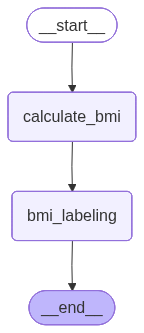

In [24]:
Image(workflow.get_graph().draw_mermaid_png())